# Setup

In [ ]:

import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.sparse as sp  
from scipy.sparse import csr_matrix
from scipy.io import mmread
import json
import decoupler as dc
import colorcet as cc

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import scrublet as scr

base_dir = "/data/scottaa/cta_onco_fetal"
os.chdir(base_dir)

In [ ]:


project_name = "ovarian_cancer_ccca"
project_dir = f"datasets/{project_name}/"
raw_data_dir = os.path.join(project_dir, "raw_data")
working_adata_dir = os.path.join(project_dir, "working_adata")
results_dir = os.path.join(project_dir, "results")
figures_dir = os.path.join(results_dir, "figures")
tables_dir = os.path.join(results_dir, "tables")




            

In [ ]:
adata_embryos = sc.read_h5ad("datasets/embryos_mixed/working_adata/embryos_mixed_female_processed_annotated.h5ad")
fetal_genes = pd.read_csv("datasets/embryos_mixed/results/tables/cta_analysis/embryos_mixed_female_cta_genes.csv")["gene"].tolist()
adata_cancer = sc.read_h5ad("datasets/ovarian_cancer_ccca/working_adata/all_ovarian_cancer_concat_annotated.h5ad")

In [53]:

with open("reference_data_common/JSON/cell_type_genes_mappings.json") as f:
    all_mappings = json.load(f)

gene_panels = all_mappings["gene_panels"]["cta_poster"]

all_genes = []
for v in gene_panels.values():
    for i in v:
        all_genes.append(i)

print(all_genes)
genes = [g for g in all_genes if g in adata_embryos.raw.var_names]
print(genes)

['PRDM1', 'PRDM14', 'TFAP2C', 'NANOS3', 'KIT', 'DPPA3', 'DAZL', 'DDX4', 'SYCP1', 'SYCE1', 'SPO11', 'HORMAD1', 'HORMAD2', 'TDRD1', 'TDRD6', 'PIWIL2', 'MAEL', 'CTCFL', 'TAF7L', 'DDX43', 'MORC1', 'PRAME', 'MAGEA4', 'MAGEC2', 'CTAG2', 'PAGE1', 'PAGE5']
['PRDM1', 'PRDM14', 'TFAP2C', 'NANOS3', 'KIT', 'DPPA3', 'DAZL', 'DDX4', 'SYCP1', 'SYCE1', 'SPO11', 'HORMAD1', 'HORMAD2', 'TDRD1', 'TDRD6', 'PIWIL2', 'MAEL', 'CTCFL', 'TAF7L', 'DDX43', 'MORC1', 'PRAME', 'MAGEA4', 'MAGEC2', 'CTAG2', 'PAGE1', 'PAGE5']


In [60]:
for project_name, adata_current, groupby in [
    ("embyros_mixed_female", adata_embryos, "celltype_leiden_res_1.0"),
    ("ovarian_cancer_ccca", adata_cancer, "celltype_leiden_res_0.5")
]:

    genes = [g for g in all_genes if g in adata_current.raw.var_names]
   

    #Fraction matrix
    adata = adata_embryos
    df = sc.get.obs_df(adata_current, keys=[groupby] + genes, use_raw=True)
    for g in genes:
        df[g] = df[g] > 0

    df_frac = df.groupby(groupby).mean()
    print(df_frac.columns)

    sc.tl.score_genes(adata_current, gene_list=genes, score_name="CTA_score", use_raw=True)

    adata_current.obs[groupby] = adata_current.obs[groupby].astype("category")
    order = (adata_current.obs.groupby(groupby)["CTA_score"].mean().sort_values(ascending=False) .index.tolist() )
    adata_current.obs[groupby] = adata_current.obs[groupby].cat.set_categories(order, ordered=True)

    #sc.pl.umap(adata_current, color="CTA_score", cmap="Purples", vmax="p99")

  #  sc.pl.violin(adata_current, "CTA_score", groupby=groupby, order=order, stripplot=False, rotation=90)
  #  sc.pl.dotplot(adata_current, var_names=genes, groupby=groupby, cmap="Purples", standard_scale="var")

/tmp/ipykernel_3562561/2277264725.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_frac = df.groupby(groupby).mean()


Index(['PRDM1', 'PRDM14', 'TFAP2C', 'NANOS3', 'KIT', 'DPPA3', 'DAZL', 'DDX4',
       'SYCP1', 'SYCE1', 'SPO11', 'HORMAD1', 'HORMAD2', 'TDRD1', 'TDRD6',
       'PIWIL2', 'MAEL', 'CTCFL', 'TAF7L', 'DDX43', 'MORC1', 'PRAME', 'MAGEA4',
       'MAGEC2', 'CTAG2', 'PAGE1', 'PAGE5'],
      dtype='object')


/tmp/ipykernel_3562561/2277264725.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = (adata_current.obs.groupby(groupby)["CTA_score"].mean().sort_values(ascending=False) .index.tolist() )
/tmp/ipykernel_3562561/2277264725.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_frac = df.groupby(groupby).mean()


Index(['PRDM1', 'KIT'], dtype='object')


/tmp/ipykernel_3562561/2277264725.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = (adata_current.obs.groupby(groupby)["CTA_score"].mean().sort_values(ascending=False) .index.tolist() )


/tmp/ipykernel_3562561/4206949807.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped_mean = df.groupby(groupby).mean()


/tmp/ipykernel_3562561/2722952483.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(groupby)["CTA_score"]
/tmp/ipykernel_3562561/2722952483.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(groupby)["CTA_score"]


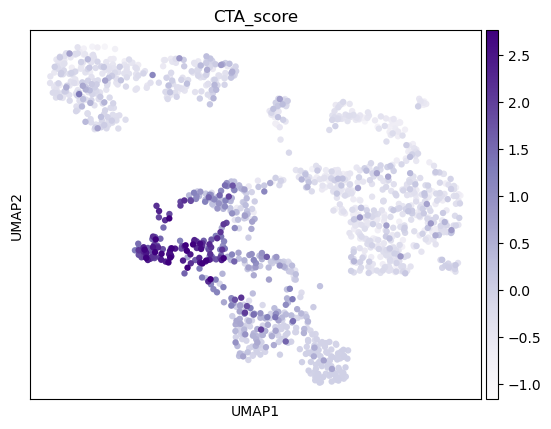

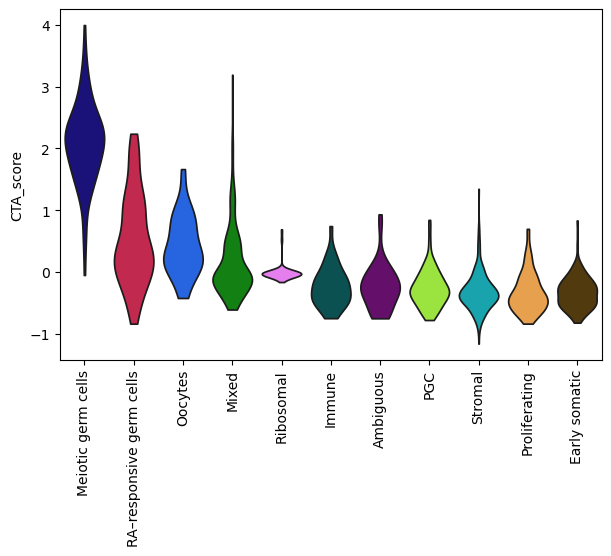

In [ ]:
# Score genes
groupby="celltype_leiden_res_1.0"

sc.tl.score_genes(adata_embryos, gene_list=fetal_genes , score_name="CTA_score", use_raw=True)

order = (
    adata_embryos.obs
    .groupby(groupby)["CTA_score"]
    .mean()
    .sort_values(ascending=False)
    .index
)
adata_embryos.obs[groupby] = adata_embryos.obs[groupby].astype("category")

order = (
    adata_embryos.obs
    .groupby(groupby)["CTA_score"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

adata_embryos.obs[groupby] = adata_embryos.obs[groupby].cat.set_categories(order, ordered=True)


In [ ]:

with open("reference_data_common/JSON/cell_type_genes_mappings.json") as f:
    annotations = json.load(f)



In [ ]:
cancer_annotations = annotations["ovarian_cancer_ccca"]['leiden_res_0.5']['cluster_to_celltype']
embryo_annotations = annotations["embryos_mixed_female"]['leiden_res_1.0']['cluster_to_celltype']

In [ ]:
df_cancer = pd.read_csv("datasets/ovarian_cancer_ccca/results/tables/ovarian_cancer_ccca_leiden_res_0.5.csv")
df_cancer ["group"] = df_cancer["group"].astype(str)
df_cancer ["cell_type"] = df_cancer ["group"].map(cancer_annotations)
df_cancer 


df_embryo = pd.read_csv("datasets/embryos_mixed/results/tables/embryos_mixed_female_leiden_res_1.0.csv")
df_embryo ["group"] = df_embryo["group"].astype(str)
df_embryo ["cell_type"] = df_embryo ["group"].map(embryo_annotations)
df_embryo 

In [ ]:
adata = sc.read_h5ad("datasets/ovarian_cancer_ccca/working_adata/all_ovarian_cancer_concat_annotated.h5ad")

In [ ]:
adata.obs.columns

In [ ]:
print("Max value:", np.max(adata.X))
print("Min value:", np.min(adata.X))